# **Entendimiento del Negocio y Carga de Datos**
---

## **0. Integrantes del equipo de trabajo**
---

1. **Kevin Andres Leal Perez** (CC 1000519441)
2. **Dairo Enrique Morales Jimenez** (CC 1006656409)
3. **Sergio Andres Sierra Garcia** (CC 1010026343)

## **1. Carga o adquisición de Datos**
---

En esta sección se describe el origen de los datos y se presenta el código para su descarga, estructuración y exploración visual inicial.

### **1.1. Origen**
---

- ¿De dónde vienen los datos?
- ¿Se usa alguna herramienta o proceso para la descarga de la información?
- ¿Qué tipo de datos estamos manejando?

### **Fuente de Datos**
El dataset proviene de la plataforma **Kaggle** y está disponible en: [RealWaste Dataset](https://www.kaggle.com/datasets/joebeachcapital/realwaste/data). Fue introducido por Single et al. (2023) y consiste en imágenes capturadas directamente en la instalación **Shoalhaven Waste Management Facility** en Nowra, Nueva Gales del Sur, Australia.

### **Características del dataset**
| Atributo | Descripción |
|----------|-------------|
| Total de imágenes | 4.752 |
| Formato | JPG |
| Resolución original | 524 × 524 píxeles |
| Resolución para InceptionV3 | 299 × 299 píxeles (preprocesamiento) |
| Número de clases | 9 |
| Herramienta de descarga | `kagglehub` |

### **Clases del dataset**
| Clase | N.º de imágenes |
|-------|-----------------|
| Cardboard | 461 |
| Food Organics | 411 |
| Glass | 420 |
| Metal | 790 |
| Miscellaneous Trash | 495 |
| Paper | 500 |
| Plastic | 921 |
| Textile Trash | 318 |
| Vegetation | 436 |

### **1.2. Carga o Adquisición de Datos**
---

In [1]:
# Instalación de dependencias
%pip install kagglehub pillow pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import kagglehub

In [3]:
# Descarga del dataset desde Kaggle
path = kagglehub.dataset_download("joebeachcapital/realwaste")
print("Ruta local del dataset:", path)

Ruta local del dataset: C:\Users\LENOVO\.cache\kagglehub\datasets\joebeachcapital\realwaste\versions\1


In [4]:
os.listdir(os.path.join(path, 'realwaste-main', 'RealWaste'))

['Cardboard',
 'Food Organics',
 'Glass',
 'Metal',
 'Miscellaneous Trash',
 'Paper',
 'Plastic',
 'Textile Trash',
 'Vegetation']

In [5]:
# Crear dataframe con rutas de imágenes y etiquetas
image_dir = os.path.join(path, 'realwaste-main', 'RealWaste')
categories = os.listdir(image_dir)
df = pd.DataFrame(columns=['image_path', 'label'])
for category in categories:
    category_dir = os.path.join(image_dir, category)
    for img_name in os.listdir(category_dir):
        img_path = os.path.join(category_dir, img_name)
        df = pd.concat([df, pd.DataFrame({'image_path': [img_path], 'label': [category]})], ignore_index=True)

In [6]:
# Vista general del DataFrame
display(df.sample(10, random_state=42).reset_index(drop=True))
print("\nConteo de imágenes por clase:")
display(df['label'].value_counts().rename('count').to_frame())

,image_path,label
0,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Metal
1,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Metal
2,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Cardboard
3,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Miscellaneous Trash
4,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Vegetation
5,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Cardboard
6,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Plastic
7,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Food Organics
8,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Miscellaneous Trash
9,C:\Users\LENOVO\.cache\kagglehub\datasets\joeb...,Plastic



Conteo de imágenes por clase:


,count
label,
Plastic,921
Metal,790
Paper,500
Miscellaneous Trash,495
Cardboard,461
Vegetation,436
Glass,420
Food Organics,411
Textile Trash,318


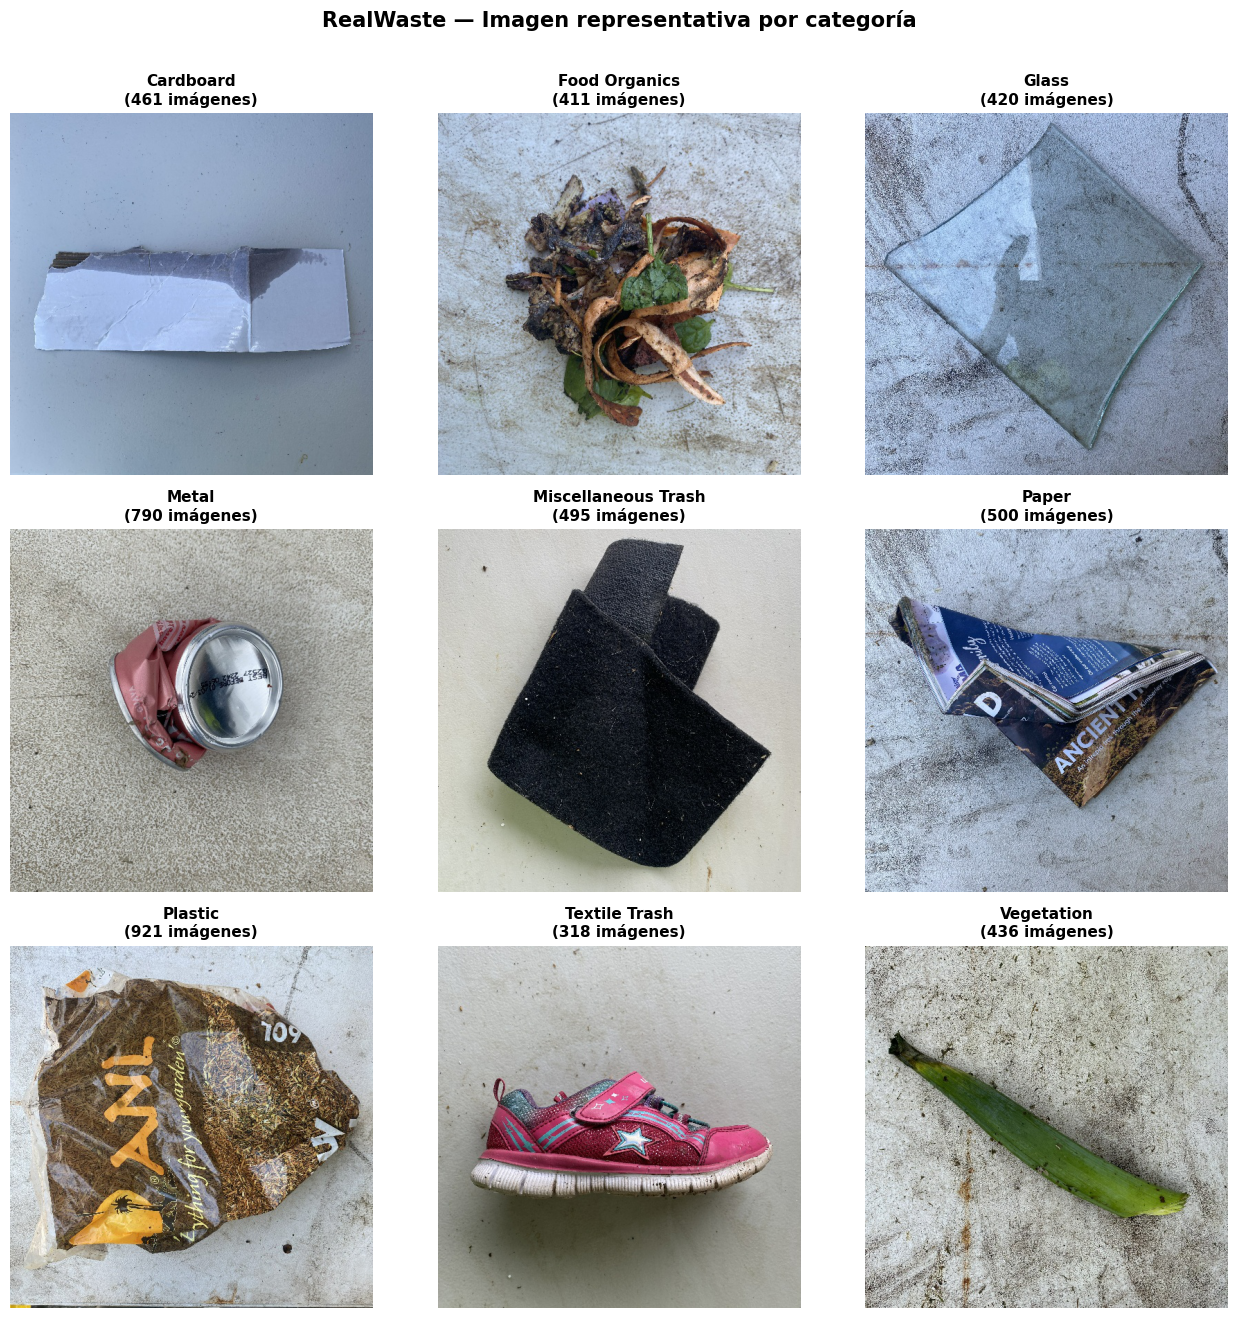

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()

for idx, category in enumerate(categories):
    cat_df = df[df["label"] == category]
    sample_path = cat_df.sample(1, random_state=42).iloc[0]["image_path"]
    img = Image.open(sample_path)
    n = len(cat_df)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{category}\n({n} imágenes)", fontsize=11, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("RealWaste — Imagen representativa por categoría",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6272\1131955574.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=35, ha="right", fontsize=10)


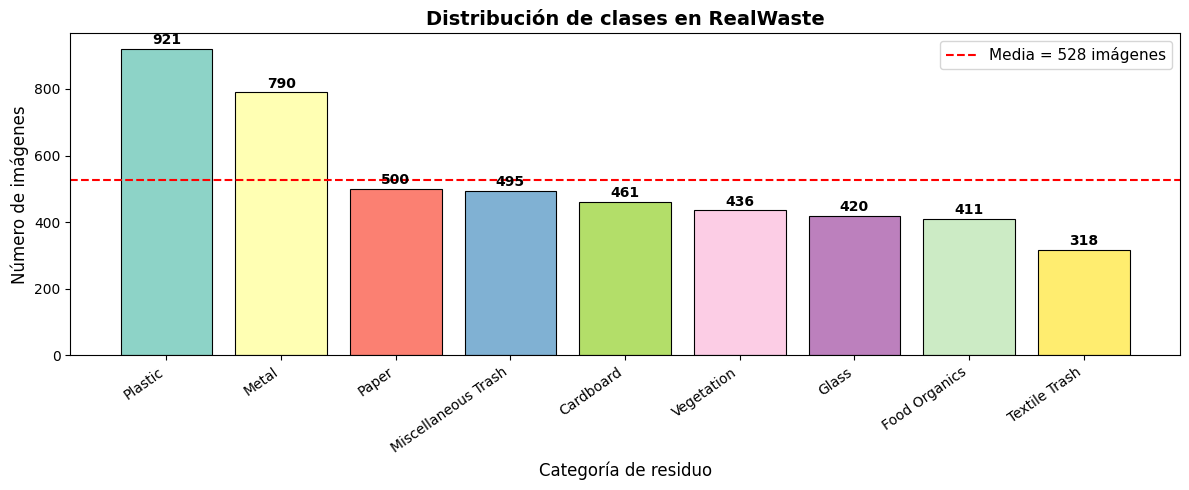

Clase con más imágenes  : Plastic (921)
Clase con menos imágenes: Textile Trash (318)
Ratio de desbalanceo    : 2.90x


In [10]:
counts = df["label"].value_counts()
palette = plt.cm.Set3(np.linspace(0, 1, len(counts)))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(counts.index, counts.values, color=palette, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 5,
            str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

mean_val = counts.mean()
ax.axhline(y=mean_val, color="red", linestyle="--", linewidth=1.5,
           label=f"Media = {mean_val:.0f} imágenes")

ax.set_xlabel("Categoría de residuo", fontsize=12)
ax.set_ylabel("Número de imágenes", fontsize=12)
ax.set_title("Distribución de clases en RealWaste", fontsize=14, fontweight="bold")
ax.set_xticklabels(counts.index, rotation=35, ha="right", fontsize=10)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Clase con más imágenes  : {counts.idxmax()} ({counts.max()})")
print(f"Clase con menos imágenes: {counts.idxmin()} ({counts.min()})")
print(f"Ratio de desbalanceo    : {counts.max() / counts.min():.2f}x")

## **2. Referencias**
---

- Single, S., Iranmanesh, S., & Raad, R. (2023). RealWaste: A Novel Real-Life Data Set for Landfill Waste Classification Using Deep Learning. *Algorithms, 16*(6), 299. https://doi.org/10.3390/a16060299
- Beach, J. (2023). RealWaste Dataset. Kaggle. Recuperado de https://www.kaggle.com/datasets/joebeachcapital/realwaste
- Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J., & Wojna, Z. (2016). Rethinking the inception architecture for computer vision. In *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)* (pp. 2818–2826).

---
## **Créditos**

* **Líder del proyecto:** Juan Sebastian Malagón Torres
* **Ingeniero de datos / ML:** Sebastián Daniel Moreno

**Universidad Nacional de Colombia** — *Facultad de Ingeniería*